In [ ]:
# Colab has most libraries pre-installed
# Run this to ensure everything is available
!pip install statsmodels --quiet
print("Libraries ready!")

Libraries ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set up visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("All libraries imported!")

All libraries imported!


In [ ]:
# Uploading insurance.csv file
from google.colab import files
uploaded = files.upload()

# Load the dataset
import io
df = pd.read_csv('insurance.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

Saving insurance.csv to insurance.csv
Dataset loaded: 1338 rows, 7 columns

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed! New shape: {df.shape}")

print("\nBasic Statistics:")
print(df.describe())

print("\nUnique Values:")
print(f"Sex: {df['sex'].unique()}")
print(f"Smoker: {df['smoker'].unique()}")
print(f"Region: {df['region'].unique()}")

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1
Duplicates removed! New shape: (1337, 7)

Basic Statistics:
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010

Unique Values:
Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'no

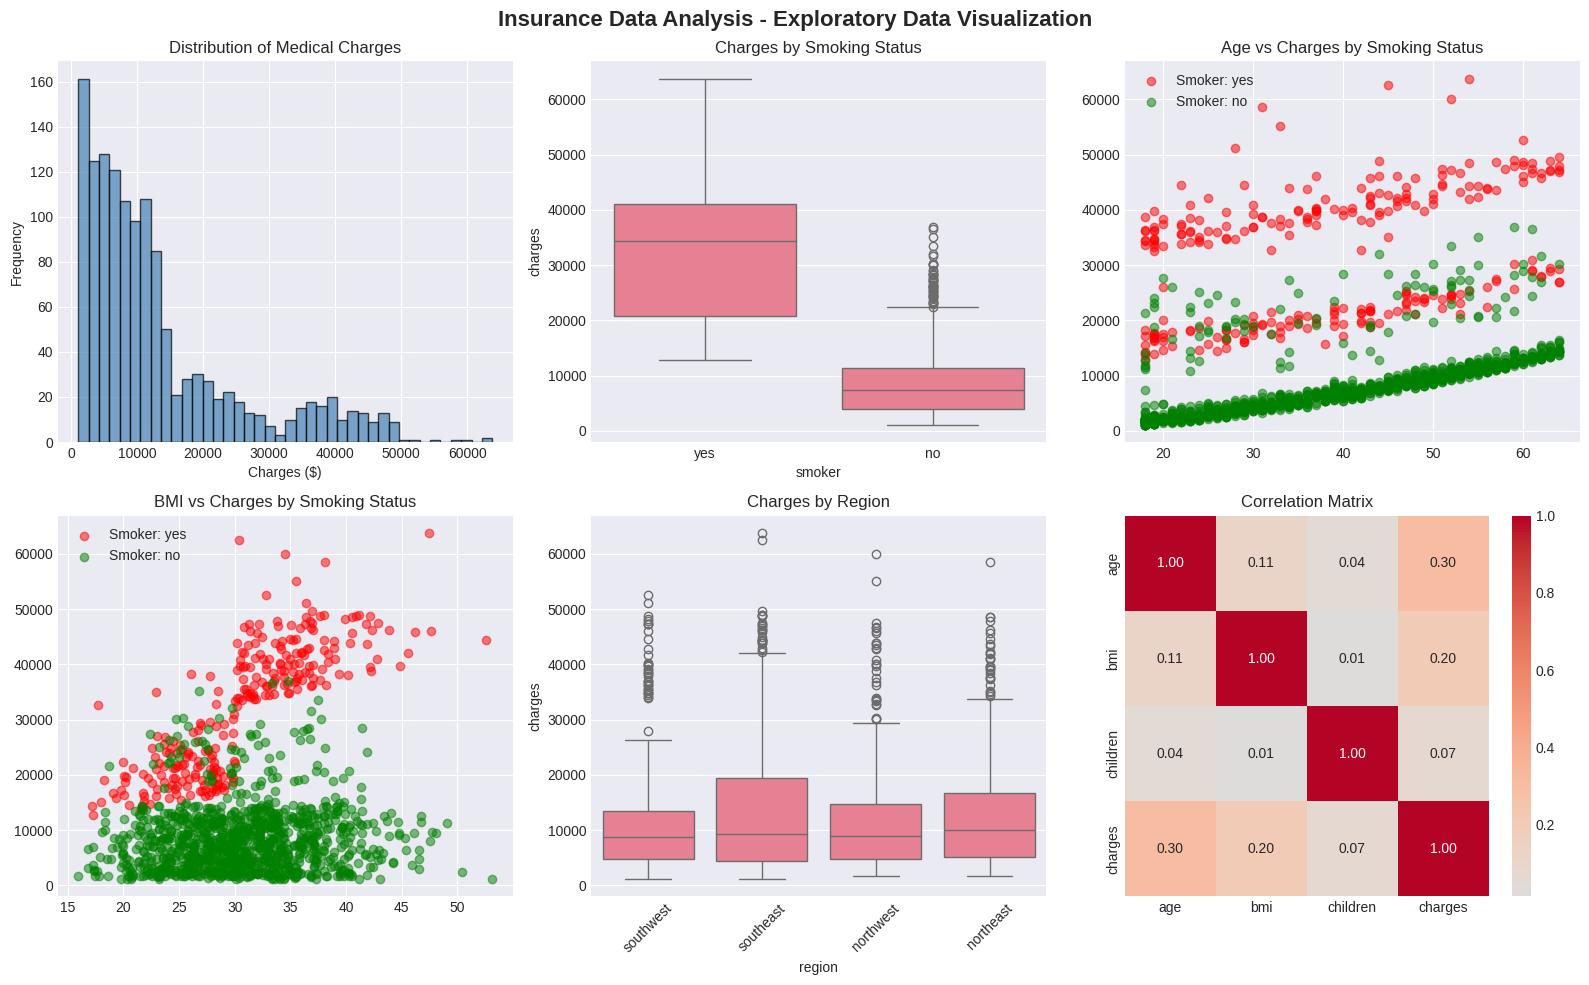

✓ Visualizations saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Insurance Data Analysis - Exploratory Data Visualization', fontsize=16, fontweight='bold')

# Plot 1: Distribution of Charges
axes[0, 0].hist(df['charges'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Medical Charges', fontsize=12)
axes[0, 0].set_xlabel('Charges ($)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Charges by Smoking Status
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Charges by Smoking Status', fontsize=12)

# Plot 3: Age vs Charges
for status, color in [('yes', 'red'), ('no', 'green')]:
    subset = df[df['smoker'] == status]
    axes[0, 2].scatter(subset['age'], subset['charges'], c=color, label=f'Smoker: {status}', alpha=0.5)
axes[0, 2].set_title('Age vs Charges by Smoking Status', fontsize=12)
axes[0, 2].legend()

# Plot 4: BMI vs Charges
for status, color in [('yes', 'red'), ('no', 'green')]:
    subset = df[df['smoker'] == status]
    axes[1, 0].scatter(subset['bmi'], subset['charges'], c=color, label=f'Smoker: {status}', alpha=0.5)
axes[1, 0].set_title('BMI vs Charges by Smoking Status', fontsize=12)
axes[1, 0].legend()

# Plot 5: Charges by Region
sns.boxplot(x='region', y='charges', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Charges by Region', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 6: Correlation Heatmap
numerical_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1, 2])
axes[1, 2].set_title('Correlation Matrix', fontsize=12)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved!")

In [ ]:
# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Define feature types
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Numerical Features: ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']

Training set: 1069 samples
Testing set: 268 samples


In [ ]:
# Create and train model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"{'Metric':<12} {'Training':<12} {'Testing':<12}")
print("-" * 36)
print(f"{'RMSE ($)':<12} ${rmse_train:>10,.2f} ${rmse_test:>10,.2f}")
print(f"{'R²':<12} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"{'MAE ($)':<12} ${mae_train:>10,.2f} ${mae_test:>10,.2f}")

MODEL PERFORMANCE
Metric       Training     Testing     
------------------------------------
RMSE ($)     $  6,081.11 $  5,956.34
R²               0.7299     0.8069
MAE ($)      $  4,181.90 $  4,177.05


In [ ]:
# Create interaction terms
X_improved = df.drop('charges', axis=1).copy()
X_improved['age_smoker'] = X_improved['age'] * (X_improved['smoker'] == 'yes').astype(int)
X_improved['bmi_smoker'] = X_improved['bmi'] * (X_improved['smoker'] == 'yes').astype(int)

numerical_features_improved = ['age', 'bmi', 'children', 'age_smoker', 'bmi_smoker']

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_improved),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_improved, y, test_size=0.2, random_state=42
)

model2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('regressor', LinearRegression())
])

model2.fit(X_train2, y_train2)
y_pred_test2 = model2.predict(X_test2)
r2_test2 = r2_score(y_test2, y_pred_test2)
rmse_test2 = np.sqrt(mean_squared_error(y_test2, y_pred_test2))

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Initial Model - Test R²: {r2_test:.4f}, RMSE: ${rmse_test:,.2f}")
print(f"Improved Model - Test R²: {r2_test2:.4f}, RMSE: ${rmse_test2:,.2f}")
print(f"\nImprovement: R² increased by {((r2_test2 - r2_test)/r2_test)*100:.1f}%")

MODEL COMPARISON
Initial Model - Test R²: 0.8069, RMSE: $5,956.34
Improved Model - Test R²: 0.8860, RMSE: $4,577.78

Improvement: R² increased by 9.8%


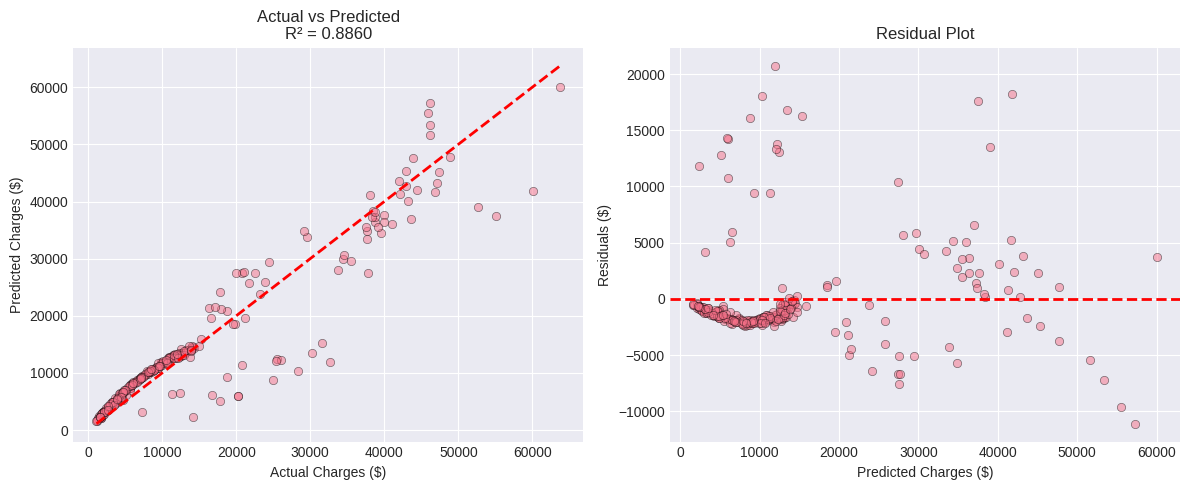

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test2, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2_test2:.4f}')

# Residuals
residuals = y_test - y_pred_test2
axes[1].scatter(y_pred_test2, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Download all generated files
from google.colab import files

# Download the visualizations
files.download('eda_visualizations.png')
files.download('model_performance.png')

# Download your notebook
!jupyter nbconvert --to html *.ipynb
print("Files ready for download!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[NbConvertApp] WARNING | pattern '*.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute t